In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
path = "/content/کامل.xlsx"
df = pd.read_excel(path)

In [3]:
# Detect required columns (fallbacks if different spacing/case)
col_year = None
col_month = None
col_target = None
for c in df.columns:
    if str(c).strip() in ["سال", "year", "Year"]:
        col_year = c
    if str(c).strip() in ["ماه", "month", "Month"]:
        col_month = c
    if str(c).strip() in ["حوزه 1", "حوزه۱", "hoze1", "Zone 1", "Domain 1"]:
        col_target = c


In [4]:
# If not found, pick last numeric column as target as a fallback
if col_target is None:
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if len(num_cols) == 0:
        raise ValueError("ستون عددی برای هدف پیدا نشد.")
    col_target = num_cols[-1]

if col_year is None or col_month is None:
    # Try to infer a datetime column if year/month missing
    dt_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    if dt_cols:
        dt_col = dt_cols[0]
        df["تاریخ"] = pd.to_datetime(df[dt_col])
    else:
        # last resort: try to parse from first column
        first = df.columns[0]
        try:
            df["تاریخ"] = pd.to_datetime(df[first])
        except Exception:
            raise ValueError("ستون‌های سال/ماه یا تاریخ پیدا نشدند.")
else:
    df["تاریخ"] = pd.to_datetime(df[col_year].astype(str) + "-" + df[col_month].astype(str), format="%Y-%m")

df = df.sort_values("تاریخ")
df = df.set_index("تاریخ")

In [5]:
# ensure monthly start freq without forcing invalid freq
df = df.asfreq("MS")

series = df[col_target].astype(float).dropna()

# Align index to monthly start (if needed)
series.index = pd.to_datetime(series.index)
series = series.asfreq("MS")

# ---------- 2) Train/test split ----------
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

# ---------- 3) Helper: ADF p-value ----------
def adf_pval(s):
    s = s.dropna()
    if len(s) < 10:
        return np.nan
    try:
        return adfuller(s, autolag="AIC")[1]
    except Exception:
        return np.nan

In [6]:
# ---------- 4) Small grid-search for (p,d,q)(P,D,Q,12) ----------
# Keep grid modest to run quickly
p_values = [0,1,2]
d_values = [0,1]
q_values = [0,1,2]
P_values = [0,1]
D_values = [0,1]
Q_values = [0,1]
s = 12


In [7]:
best = {"aic": np.inf, "order": None, "seasonal_order": None, "res": None}

for d in d_values:
    for D in D_values:
        for p in p_values:
            for q in q_values:
                for P in P_values:
                    for Q in Q_values:
                        order = (p, d, q)
                        seasonal_order = (P, D, Q, s)
                        try:
                            model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                                            enforce_stationarity=False, enforce_invertibility=False)
                            res = model.fit(disp=False)
                            if res.aic < best["aic"]:
                                best = {"aic": res.aic, "order": order, "seasonal_order": seasonal_order, "res": res}
                        except Exception:
                            continue
best_order = best["order"]
best_seasonal_order = best["seasonal_order"]
res = best["res"]

In [8]:
 # ---------- 5) Forecast on test and metrics ----------
steps = len(test)
fc = res.get_forecast(steps=steps)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

In [9]:
rmse = mean_squared_error(test, fc_mean)
mae = mean_absolute_error(test, fc_mean)
mape = (np.abs((test - fc_mean) / test).replace([np.inf, -np.inf], np.nan).dropna() * 100).mean()


In [10]:
# ---------- 6) Fit on full data & forecast 12 months ahead ----------
full_model = SARIMAX(series, order=best_order, seasonal_order=best_seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
full_res = full_model.fit(disp=False)

future_steps = 12
future_fc = full_res.get_forecast(steps=future_steps)
future_mean = future_fc.predicted_mean
future_ci = future_fc.conf_int()

In [11]:
# ---------- 7) Save results ----------
summary_info = {
    "best_order": best_order,
    "best_seasonal_order": best_seasonal_order,
    "best_aic": best["aic"],
    "adf_pvalue_train": adf_pval(train),
    "adf_pvalue_diff1": adf_pval(train.diff()),
    "adf_pvalue_seasonal_diff": adf_pval(train.diff(12)),
    "rmse_test": rmse,
    "mae_test": mae,
    "mape_test_percent": mape
}
summary_df = pd.DataFrame([summary_info])
summary_df

,best_order,best_seasonal_order,best_aic,adf_pvalue_train,adf_pvalue_diff1,adf_pvalue_seasonal_diff,rmse_test,mae_test,mape_test_percent
0,"(1, 1, 2)","(1, 1, 1, 12)",1975.943823,0.924224,0.000031,0.04753,3.452357e+13,4.915292e+06,10.187368


In [12]:
# Compile forecast table
out = pd.DataFrame({
    "actual_test": test,
    "pred_test": fc_mean.reindex(test.index)
})
out_future = pd.DataFrame({
    "forecast_mean": future_mean,
    "lower": future_ci.iloc[:,0],
    "upper": future_ci.iloc[:,1]
})


In [13]:
summary_path = (r"C:\Users\ASUS\Desktop\sarima_summary.xlsx")
test_fc_path = (r"C:\Users\ASUS\Desktop\sarima_test_forecast.xlsx")
future_fc_path = (r"C:\Users\ASUS\Desktop\sarima_future12.xlsx")

In [14]:
summary_df.to_csv(summary_path, index=False)
out.to_csv(test_fc_path)
out_future.to_csv(future_fc_path)

Text(0.5, 1.0, 'SARIMA: Train/Test Forecast')

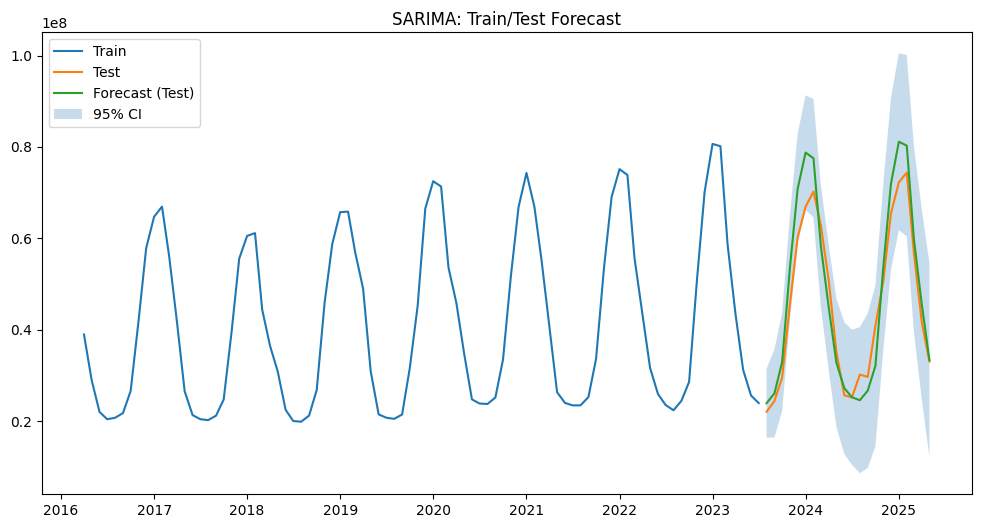

In [15]:
# ---------- 8) Plots ----------
# Train/Test + forecast plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(fc_mean.index, fc_mean, label="Forecast (Test)")
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.25, label="95% CI")
plt.legend()
plt.title("SARIMA: Train/Test Forecast")

Text(0.5, 1.0, 'SARIMA: Next 12 Months Forecast')

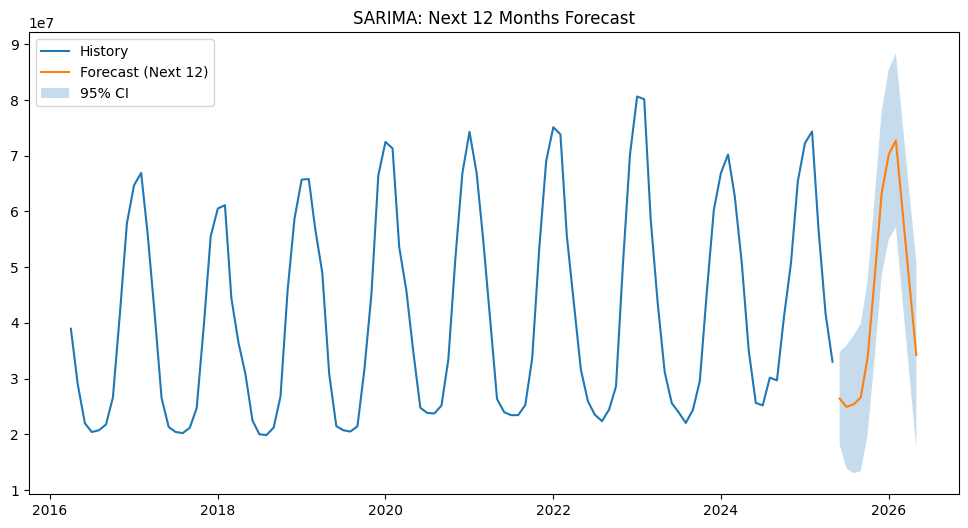

In [16]:
# Future 12-month forecast plot
plt.figure(figsize=(12,6))
plt.plot(series.index, series, label="History")
plt.plot(future_mean.index, future_mean, label="Forecast (Next 12)")
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], alpha=0.25, label="95% CI")
plt.legend()
plt.title("SARIMA: Next 12 Months Forecast")

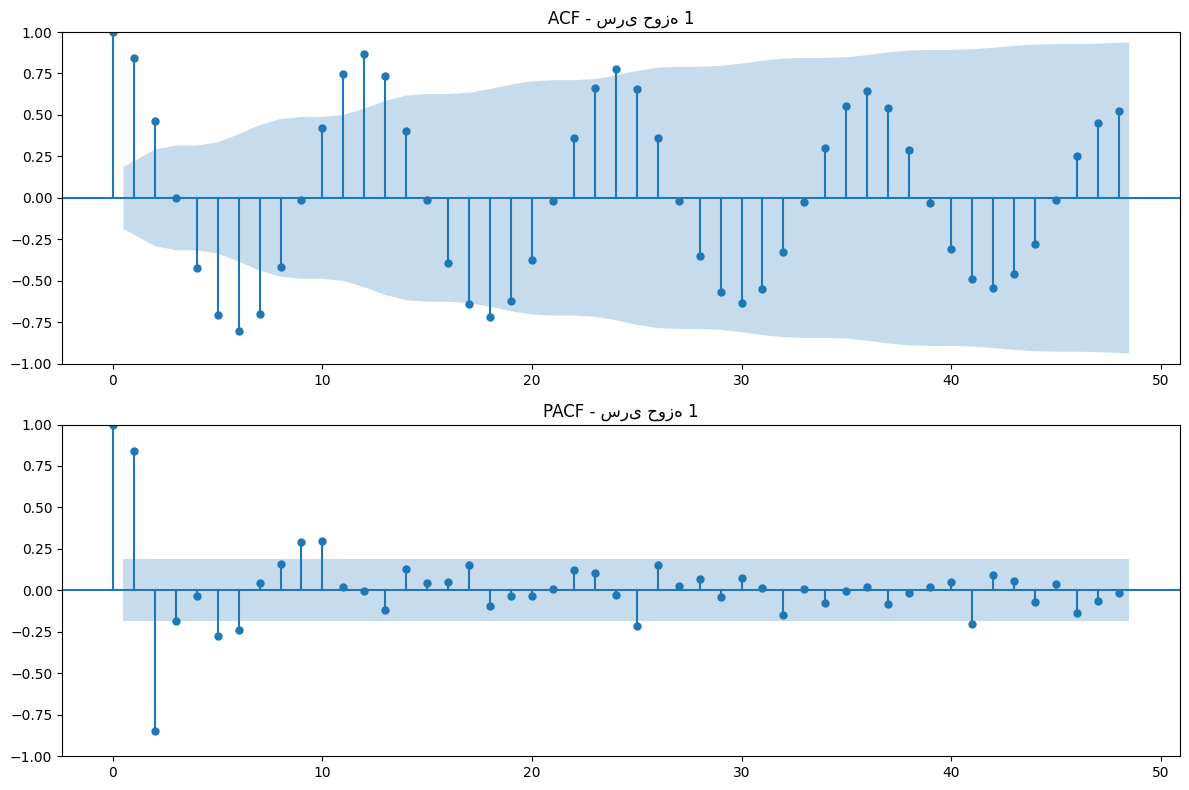

In [19]:
# مشکل به خاطر گپ یا ترتیب تاریخ‌هاست. به جای set کردن freq مستقیم، از asfreq یا infer_freq استفاده می‌کنیم.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# بارگذاری داده‌ها
target = pd.read_excel("/content/کامل.xlsx")

# ساخت ستون تاریخ
target['تاریخ'] = pd.to_datetime(target['سال'].astype(str) + '-' + target['ماه'].astype(str), format='%Y-%m')
target = target.sort_values('تاریخ')
target.set_index('تاریخ', inplace=True)

# تلاش برای شناسایی فرکانس
try:
    target.index.freq = pd.infer_freq(target.index)
except:
    target = target.asfreq('MS')

# انتخاب سری حوزه 1
y = target['حوزه 1'].dropna()

# رسم نمودار ACF و PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y, lags=48, ax=axes[0])
plot_pacf(y, lags=48, ax=axes[1])
axes[0].set_title("ACF - سری حوزه 1")
axes[1].set_title("PACF - سری حوزه 1")
plt.tight_layout()
plt.show()


In [20]:
# Fix the plotting issue by ensuring numeric arrays for fill_between

import numpy as np
import matplotlib.pyplot as plt

# Recreate local objects from previous cell (they exist in state)
# Use numeric arrays for the CI bounds
x1 = fc_mean.index
y1 = fc_ci.iloc[:, 0].astype(float).values
y2 = fc_ci.iloc[:, 1].astype(float).values


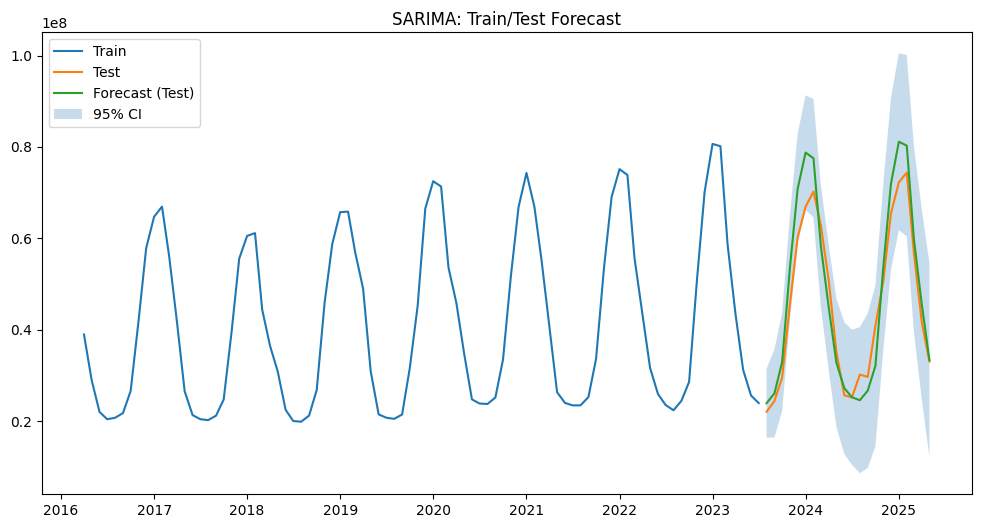

In [21]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(fc_mean.index, fc_mean, label="Forecast (Test)")
plt.fill_between(x1, y1, y2, alpha=0.25, label="95% CI")
plt.legend()
plt.title("SARIMA: Train/Test Forecast")
plt.show()


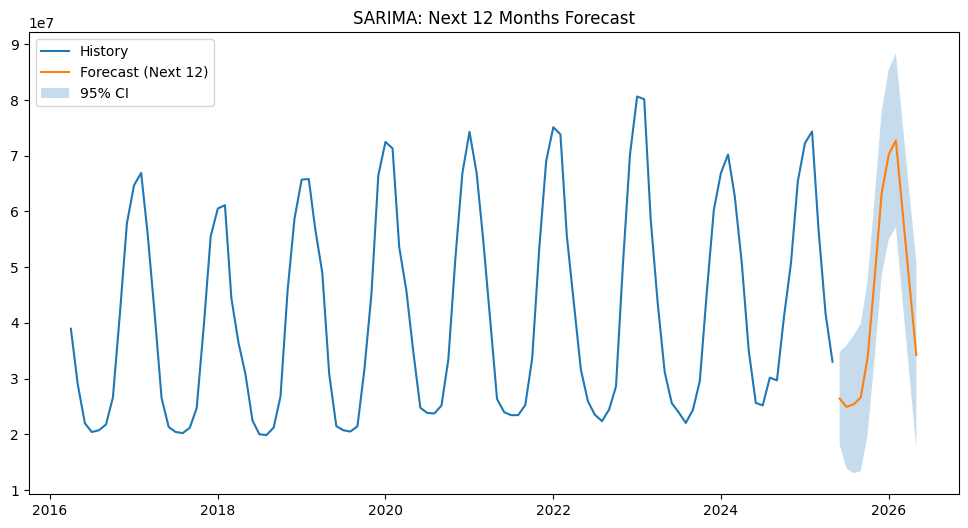

In [22]:
# Future forecast plot
x2 = future_mean.index
y1f = future_ci.iloc[:, 0].astype(float).values
y2f = future_ci.iloc[:, 1].astype(float).values

plt.figure(figsize=(12,6))
plt.plot(series.index, series, label="History")
plt.plot(future_mean.index, future_mean, label="Forecast (Next 12)")
plt.fill_between(x2, y1f, y2f, alpha=0.25, label="95% CI")
plt.legend()
plt.title("SARIMA: Next 12 Months Forecast")
plt.show()


In [23]:
# Print concise summary stats to the output cell
print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test MAPE (%):", mape)

Best order: (1, 1, 2)
Best seasonal order: (1, 1, 1, 12)
Test RMSE: 34523568863089.652
Test MAE: 4915292.224700802
Test MAPE (%): 10.187368403336421
